In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ameergul1234/bank-churn-prediction-dataset/Bank Customer Churn Prediction.csv


In [54]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score,roc_curve)

from xgboost import XGBClassifier
sns.set_style("darkgrid")
pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("/kaggle/input/datasets/ameergul1234/bank-churn-prediction-dataset/Bank Customer Churn Prediction.csv")

In [5]:
print ( "Data Shape",df.shape)
df.head()

Data Shape (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [7]:
df = df.drop(columns=['customer_id'])

df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
print("Missing values")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Duplicate rows: 0


In [9]:
# Count the number of customers in each class
print(df['churn'].value_counts())
print(df['churn'].value_counts(normalize=True) * 100)

churn
0    7963
1    2037
Name: count, dtype: int64
churn
0    79.63
1    20.37
Name: proportion, dtype: float64


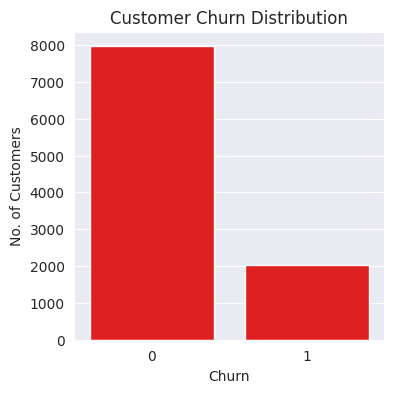

In [55]:
plt.figure(figsize=(4,4))

sns.countplot(x='churn', data=df, color='red')

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("No. of Customers")

plt.show()

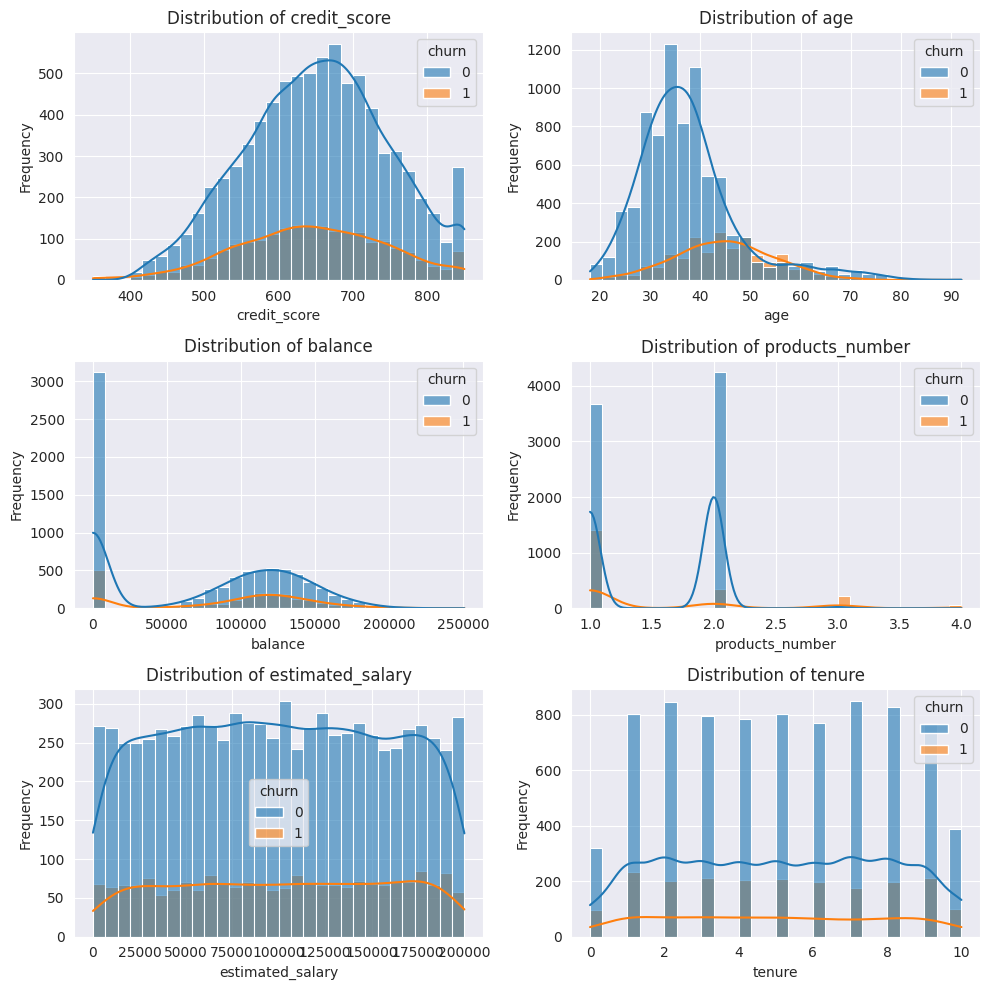

In [56]:
numeric_features = ['credit_score', 'age','balance', 'products_number','estimated_salary','tenure']

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()
for i, column in enumerate(numeric_features):
    sns.histplot( data=df, x=column, kde=True,hue="churn", ax=axes[i] , bins=30 , alpha=0.6 )
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')


plt.tight_layout()
plt.show()

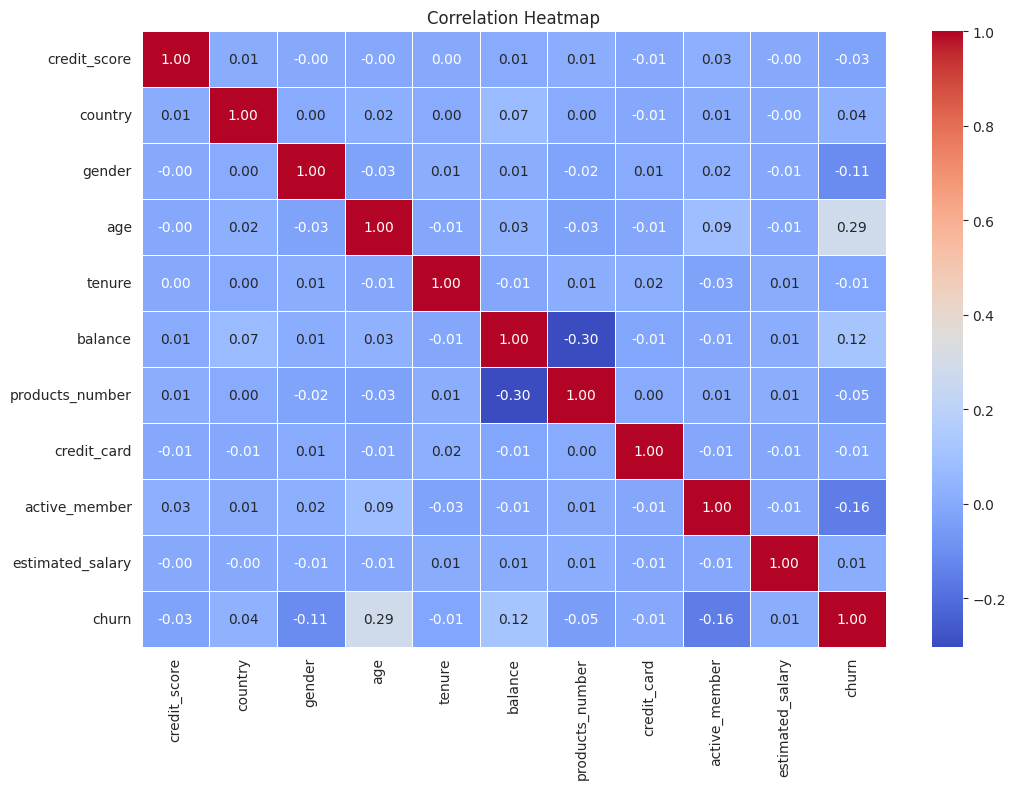

In [31]:

corr_df = df.copy()

le = LabelEncoder()
corr_df['country'] = le.fit_transform(corr_df['country'])
corr_df['gender'] = le.fit_transform(corr_df['gender'])

plt.figure(figsize=(12,8))

sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm',fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap')
plt.show()

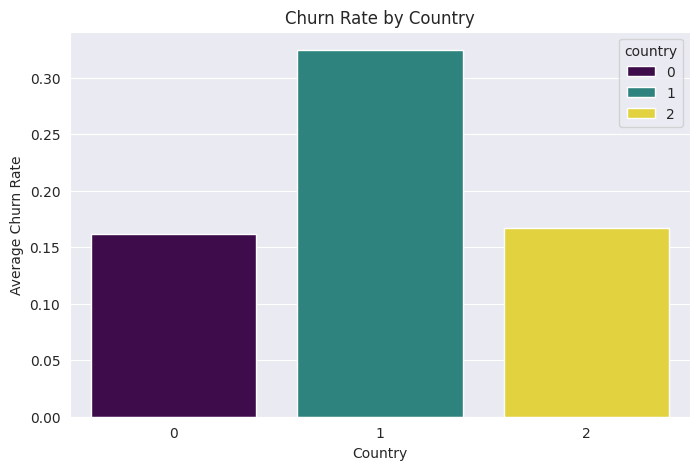

In [57]:
country_churn = df.groupby('country', as_index=False)['churn'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    data=country_churn,
    x='country',
    y='churn',
    hue='country',
    palette='viridis'
)

plt.title("Churn Rate by Country")
plt.xlabel("Country")
plt.ylabel("Average Churn Rate")

plt.show()

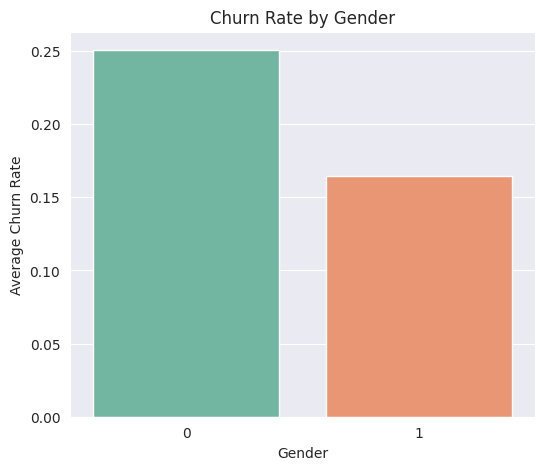

In [58]:
# Calculate the average churn rate by gender
gender_churn = df.groupby('gender', as_index=False)['churn'].mean()

plt.figure(figsize=(6,5))

sns.barplot(
    data=gender_churn,
    x='gender',
    y='churn',
    hue='gender',
    palette='Set2',
    legend=False
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Churn Rate")

plt.show()

# The dataset is imbalanced, because 80% of customers didn't churn and 20% leave the bank.
# the strongest individual relationship is ( Age ) because that means the older people more likely to leave the bank.
# 

In [36]:
df = df.copy()
df['AgeGroup'] = (df_fe['age'] // 10) * 10
df['IsSenior'] = (df_fe['age'] >= 60).astype(int)

df['QualityOfBalance'] = pd.cut( df['balance'],bins=5,labels=[0, 1, 2, 3, 4]).astype(int)

df['Balance_to_Salary_Ratio'] = (df['balance'] / df['estimated_salary'])

df['Balance_to_Salary_Ratio'] = df['Balance_to_Salary_Ratio'].replace([np.inf, -np.inf], 0)

df['Balance_to_Salary_Ratio'] = df['Balance_to_Salary_Ratio'].fillna(0)

df['CreditScoreTier'] = pd.cut( df['credit_score'],bins=[0, 650, 750, 900], labels=[0, 1, 2], include_lowest=True).astype(int)

df['IsActive_by_CreditCard'] = ( df['credit_card'] * df['active_member'])

df['Products_Per_Tenure'] = (df['tenure'] / df['products_number'].replace(0, 1))

df['Customer_Status'] = ( df['tenure'] >= 2).astype(int)

country_encoder = LabelEncoder()
gender_encoder = LabelEncoder()

country_encoded = country_encoder.fit_transform(df['country'])
gender_encoded = gender_encoder.fit_transform(df['gender'])

df['Geo_Gender'] = (country_encoded + gender_encoded +10)

print("Shape after feature engineering:", df.shape)
df.head()

Shape after feature engineering: (10000, 20)


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,AgeGroup,IsSenior,QualityOfBalance,Balance_to_Salary_Ratio,CreditScoreTier,IsActive_by_CreditCard,Products_Per_Tenure,Customer_Status,Geo_Gender
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,40,0,0,0.000000,0,1,2.000000,1,10
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,40,0,1,0.744677,0,0,1.000000,0,12
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,40,0,3,1.401375,0,0,2.666667,1,10
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,30,0,0,0.000000,1,0,0.500000,0,10
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,40,0,2,1.587055,2,1,2.000000,1,12


In [40]:
X = df_fe.drop('churn', axis=1)
y = df_fe['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42,  stratify=y)

country_encoder = LabelEncoder()
gender_encoder = LabelEncoder()

X_train['country'] = country_encoder.fit_transform(X_train['country'])
X_train['gender'] = gender_encoder.fit_transform(X_train['gender'])


X_test['country'] = country_encoder.transform(X_test['country'])
X_test['gender'] = gender_encoder.transform(X_test['gender'])

print("Data Types:")
print(X_train.dtypes)

print("\n" + "="*50)

print("Training Set Shape :", X_train.shape)
print("Testing Set Shape  :", X_test.shape)

print("\nTraining Churn Rate :", round(y_train.mean(), 4))
print("Testing Churn Rate  :", round(y_test.mean(), 4))

Data Types:
credit_score                 int64
country                      int64
gender                       int64
age                          int64
tenure                       int64
balance                    float64
products_number              int64
credit_card                  int64
active_member                int64
estimated_salary           float64
AgeGroup                     int64
IsSenior                     int64
QualityOfBalance             int64
Balance_to_Salary_Ratio    float64
CreditScoreTier              int64
IsActive_by_CreditCard       int64
Products_Per_Tenure        float64
Customer_Status              int64
Geo_Gender                   int64
dtype: object

Training Set Shape : (8000, 19)
Testing Set Shape  : (2000, 19)

Training Churn Rate : 0.2037
Testing Churn Rate  : 0.2035


In [42]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"Negatives: {neg}  |  Positives: {pos}  |  scale_pos_weight: {scale_pos_weight:.2f}")

Negatives: 6370  |  Positives: 1630  |  scale_pos_weight: 3.91


In [46]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier( n_estimators=300,learning_rate=0.1,max_depth=6, 
                          random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_model.fit(X_train, y_train)

print(" ::: XGBoost trained successfully :::")

 ::: XGBoost trained successfully :::


In [51]:
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,target_names=["Stayed", "Churned"]))

ROC-AUC Score: 0.8382

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.95      0.91      1593
     Churned       0.70      0.47      0.57       407

    accuracy                           0.85      2000
   macro avg       0.79      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000



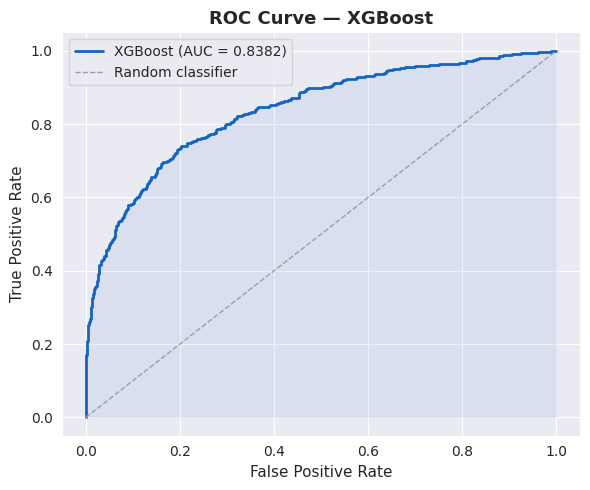

In [59]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="#1565C0", lw=2, label=f"XGBoost (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="#9E9E9E", linestyle="--", lw=1, label="Random classifier")
ax.fill_between(fpr, tpr, alpha=0.08, color="#1565C0")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve — XGBoost", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()